# Detetação de Fake News com Text Mining
Projeto para a unidade curricular Text Mining Feito por: Alba Pando Nº123609, André Santos Nº123579, Bruno Oliveira Nº, Filipe Brites Nº123584, Natacha Pulga Nº123656

Este trabalho blah blah text mining blah blah deteção de Fake News

# Instalação de bibliotecas
Nesta etapa são instaladas todas as dependências necessárias para a execução do projeto.

In [3]:
# Instalar as dependências necessárias do projeto
%pip install -r requirements.txt

  Obtaining dependency information for nltk>=3.8 from https://files.pythonhosted.org/packages/9d/91/04e965f8e717ba0ab4bdca5c112deeab11c9e750d94c4d4602f050295d39/nltk-3.9.4-py3-none-any.whl.metadata
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/ae/44/c1221527f6a71a01ec6fbad7fa78f1d50dfa02217385cf0fa3eec7087d59/click-8.3.3-py3-none-any.whl.metadata
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Obtaining dependency information for regex>=2021.8.3 from https://files.pythonhosted.org/packages/d0/b0/8dce459f6245bcf8f6e9f23ac9569f1a0f15c131cc0745e82b43226204cf/regex-2026.5.9-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 503.8 kB/s eta 0:00:00
  Obtaining dependency information 


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importar as bibliotecas necessárias
Nesta secção importamos todas as bibliotecas utilizadas no projeto.

In [4]:
#Importar bibliotecas
import html
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Fazer download dos pacotes necessários do NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Configurações para visualização e warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

# Configura o pandas para não esconder colunas
pd.set_option('display.max_columns', None)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Carregamento de Dados
Nesta fase é realizado o carregamento dos datasets utilizados no projeto. Cada conjunto de dados corresponde a uma classe diferente de notícias: notícias verdadeiras e notícias falsas.

Após a leitura dos ficheiros CSV, são adicionadas colunas de identificação das classes (`label` e `label_name`).

Por fim, os datasets são combinados num único DataFrame.

In [5]:
def load_data(path, label, label_name):
    df = pd.read_csv(path)
    
    df["label"] = label
    df["label_name"] = label_name
    return df

#Ler ambos csvs
df_true = load_data("data/True.csv", 0, "true")
df_false = load_data("data/Fake.csv", 1, "fake")

#vamos juntar ambas databases :)
df_total = pd.concat([df_true, df_false], ignore_index=True)

# Preencher valores nulos e garantir que as colunas de texto sejam do tipo string
for column in ["title", "text", "subject", "date"]:
    df_total[column] = df_total[column].fillna("").astype(str)

# Criar a coluna "document" concatenando "title" e "text", e calcular os comprimentos
df_total["document"] = (df_total["title"].str.strip() + ". " + df_total["text"].str.strip()).str.strip()
df_total["title_length"] = df_total["title"].str.split().str.len()
df_total["text_length"] = df_total["text"].str.split().str.len()
df_total["document_length"] = df_total["document"].str.split().str.len()

#randomizing a database para as linhas com diferentes classes estarem mistruradas
df_total = df_total.sample(frac=1).reset_index(drop=True)

# remover duplicados
before = len(df_total)
df_total = df_total.drop_duplicates(subset=["title", "text", "label"]).reset_index(drop=True)
after = len(df_total)

print(f"Documentos antes de remover duplicados: {before}")
print(f"Documentos depois de remover duplicados: {after}")
display(df_total.head())

# export dataframe to csv
df_total.to_csv('data/total.csv', index=False)

Documentos antes de remover duplicados: 44898
Documentos depois de remover duplicados: 39105


,title,text,subject,date,label,label_name,document,title_length,text_length,document_length
0,Opposition MPs walk out on South Africa's Zuma...,CAPE TOWN (Reuters) - Jacob Zuma told South Af...,worldnews,"November 2, 2017",0,true,Opposition MPs walk out on South Africa's Zuma...,10,451,461
1,Trump picks Rep. Mulvaney to head White House ...,(Reuters) - President-elect Donald Trump will ...,politicsNews,"December 16, 2016",0,true,Trump picks Rep. Mulvaney to head White House ...,10,169,179
2,Twitter DESTROYS Trump For Irony Of Screaming...,Break out the popcorn Donald Trump got busy ...,News,"September 5, 2016",1,fake,Twitter DESTROYS Trump For Irony Of Screaming ...,14,548,562
3,WATCH: New Documentary Explores Trump’s Russi...,This past week the world has been hit with man...,News,"May 16, 2017",1,fake,WATCH: New Documentary Explores Trump’s Russia...,8,248,256
4,"Russia's Putin: our work with Turkey, Iran is ...","SOCHI, Russia (Reuters) - President Vladimir P...",worldnews,"November 13, 2017",0,true,"Russia's Putin: our work with Turkey, Iran is ...",12,51,63


# Análise exploratória dos Dados
Nesta análise são calculadas métricas estatísticas para cada classe de notícias.

O objetivo é comparar notícias verdadeiras e falsas em termos de:

- Número total de documentos;
- Quantidade de assuntos distintos;
- Comprimento médio dos títulos;
- Comprimento médio do texto completo.

Estas métricas permitem perceber diferenças estruturais entre os dois tipos de notícias, o que pode contribuir para a capacidade de classificação dos modelos.

In [6]:
# Análise exploratória dos dados - Estatísticas descritivas por classe
dataset_stats = (
    df_total.groupby("label_name")
    .agg(
        documents=("document", "count"),
        unique_subjects=("subject", "nunique"),
        avg_title_words=("title_length", "mean"),
        avg_text_words=("text_length", "mean"),
        median_text_words=("text_length", "median"),
        min_text_words=("text_length", "min"),
        max_text_words=("text_length", "max"),
    )
    .round(2)
)

display(dataset_stats)

,documents,unique_subjects,avg_title_words,avg_text_words,median_text_words,min_text_words,max_text_words
label_name,,,,,,,
fake,17908,6,14.32,414.69,371.0,0,8135
true,21197,2,9.95,384.86,359.0,0,5172


O gráfico seguinte apresenta a distribuição das notícias por classe.
Esta visualização permite verificar se existe equilíbrio entre notícias verdadeiras e falsas.

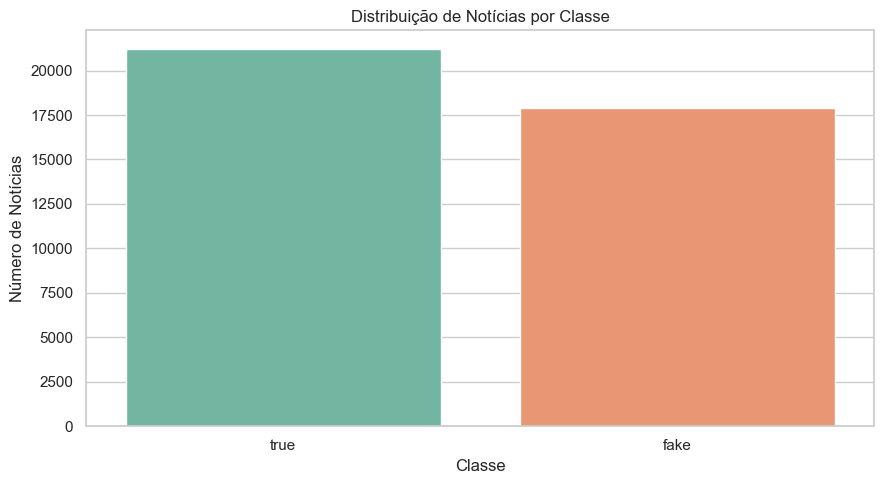

In [7]:
# Visualização da distribuição de notícias por classe
counts = df_total["label_name"].value_counts()
colors = ['#66C2A5', '#FC8D62']

ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
ax.set_title("Distribuição de Notícias por Classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de Notícias")
plt.tight_layout()
plt.show()

Nesta visualização analisamos a quantidade de notícias associadas a cada assunto dentro de cada classe.

In [8]:
# Análise da distribuição de notícias por assunto dentro de cada classe
subject_distribution = (
    df_total.groupby(["label_name", "subject"])
    .size()
    .reset_index(name="documents")
    .sort_values(["label_name", "documents"], ascending=[True, False])
)

display(subject_distribution)

,label_name,subject,documents
2,fake,News,9050
5,fake,politics,4596
4,fake,left-news,2546
0,fake,Government News,933
3,fake,US_News,410
1,fake,Middle-east,373
6,true,politicsNews,11211
7,true,worldnews,9986


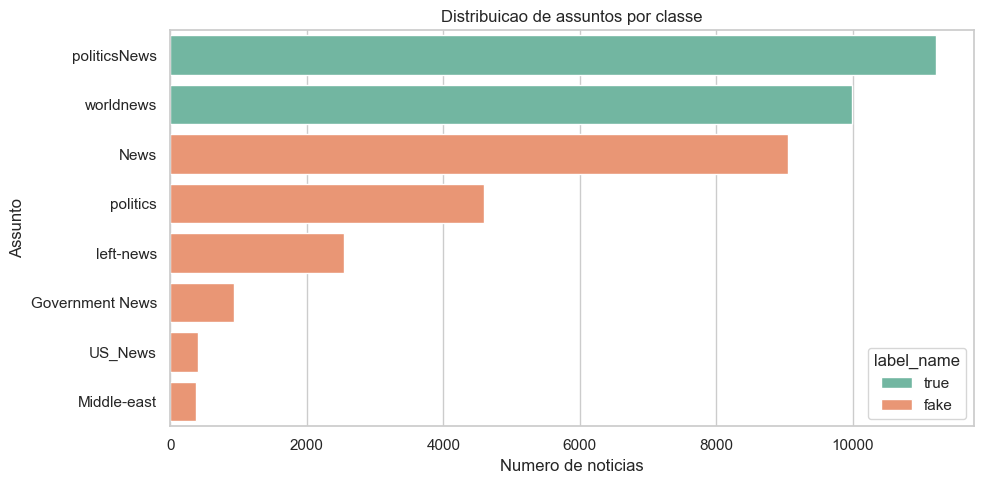

In [29]:
# Visualização da distribuição de assuntos por classe
plt.figure(figsize=(10, 5))
ordered_subjects = subject_distribution.sort_values("documents", ascending=False)["subject"]
ax = sns.countplot(data=df_total, y="subject", order=ordered_subjects, hue="label_name", palette=['#66C2A5', '#FC8D62'])
ax.set_title("Distribuicao de assuntos por classe")
ax.set_xlabel("Numero de noticias")
ax.set_ylabel("Assunto")
plt.tight_layout()
plt.show()

Este gráfico apresenta a distribuição do tamanho dos documentos após a junção do título e do texto.

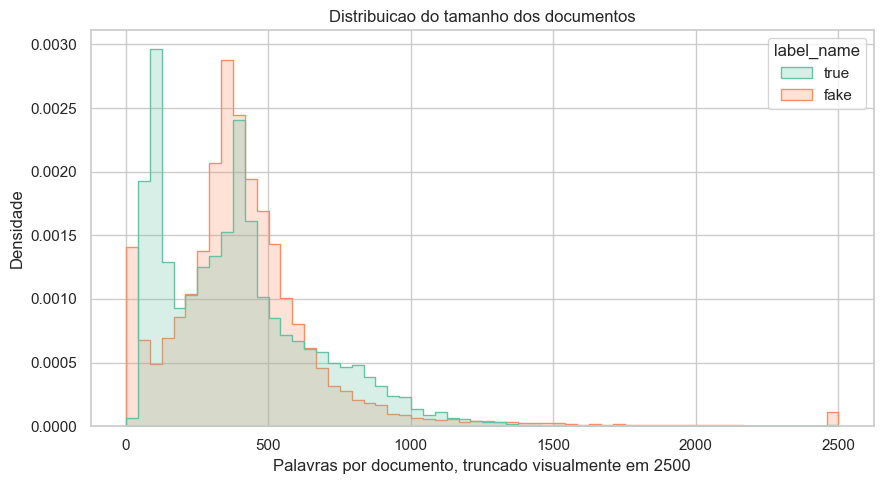

In [30]:
# Visualização da distribuição de tamanho dos documentos por classe
plot_df = df_total.assign(document_length_clipped=df_total["document_length"].clip(upper=2500))
ax = sns.histplot(
    data=plot_df,
    x="document_length_clipped",
    hue="label_name",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    palette=['#66C2A5', '#FC8D62']
)
ax.set_title("Distribuicao do tamanho dos documentos")
ax.set_xlabel("Palavras por documento, truncado visualmente em 2500")
ax.set_ylabel("Densidade")
plt.tight_layout()
plt.show()

# Pré-processamento dos dados
Nesta secção os textos são limpos e normalizados para remover elementos irrelevantes que podem prejudicar a aprendizagem dos modelos.

Entre as operações realizadas encontram-se:

- Remoção de URLs, emails e hashtags;
- Remoção de HTML e caracteres especiais;
- Conversão para minúsculas;
- Remoção de stopwords;
- Normalização textual.

A função `clean_text()` é responsável por realizar o processamento e limpeza dos documentos.

O objetivo desta função é transformar os textos numa versão mais consistente e adequada para análise automática.

In [11]:
# Configurações para limpeza de texto
stop_words = set(stopwords.words('english'))

# Expressões regulares para limpeza de texto
URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b")
TWITTER_RE = re.compile(r"@\w+|#\w+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")
REUTERS_DATELINE_RE = re.compile(
    r"^\s*[A-Z][A-Z\s.,'-]{2,}\s+\(Reuters\)\s*-\s*", flags=re.IGNORECASE
) # Padrão para datelines do Reuters, como "LONDON (Reuters) - " ou "NEW YORK (Reuters) - visto que aparecia muito nos textos"

# Função para remover acentos de um texto
def strip_accents(text):
    normalized = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in normalized if not unicodedata.combining(ch))

def clean_text(text, remove_stopwords = True):
    text = html.unescape(text)
    text = REUTERS_DATELINE_RE.sub("", text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = EMAIL_RE.sub(" EMAIL ", text)
    text = TWITTER_RE.sub(" ", text)
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = strip_accents(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    tokens = WHITESPACE_RE.sub(" ", text).strip().split()
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return " ".join(tokens)

In [12]:
# Testar a função de limpeza num exemplo
example = df_total.loc[0, "document"]
print("ANTES:\n", example[:700])
print("\nDEPOIS:\n", clean_text(example)[:700])

ANTES:
 Opposition MPs walk out on South Africa's Zuma over corruption. CAPE TOWN (Reuters) - Jacob Zuma told South Africa s parliament on Thursday he had received no payments from private companies or individuals during his time as president, as opposition lawmakers walked out in protest over the cost to the state of his legal fees.  Allegations by government and opposition politicians that the wealthy Gupta family of businessmen used a friendship with Zuma to control state businesses and influence appointments are among many scandals that have dogged his presidency.      The Guptas and Zuma have denied any wrongdoing and say they are victims of a politically motivated witch-hunt.  My government is

DEPOIS:
 jacob zuma told south africa parliament thursday received payments private companies individuals time president opposition lawmakers walked protest cost state legal fees allegations government opposition politicians wealthy gupta family businessmen used friendship zuma control sta

# Preparação para o Treino e Teste
Após o pré-processamento, os documentos limpos são utilizados para criar os conjuntos de treino e teste.

A divisão dos dados é realizada utilizando a técnica `train_test_split`, garantindo que:

- O modelo é treinado apenas com parte dos dados;
- O desempenho é avaliado em dados nunca vistos anteriormente;
- A proporção das classes é mantida através da estratificação.

In [13]:
# Aplicar a função de limpeza a toda a coluna "document" e criar uma nova coluna "clean_document"
df_total["clean_document"] = df_total["document"].map(clean_text)

# Dividir os dados em conjuntos de treino e teste, mantendo a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    df_total["clean_document"],
    df_total["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_total["label"],
)

print("Treino:", X_train.shape[0])
print("Teste:", X_test.shape[0])
print("Distribuicao no treino:")
print(y_train.value_counts(normalize=True).rename({0: "true", 1: "fake"}))

Treino: 31284
Teste: 7821
Distribuicao no treino:
label
true    0.542066
fake    0.457934
Name: proportion, dtype: float64


# Modelação e Técnicas

## Modelos Supervisionados
Nesta secção são definidos os modelos de Machine Learning utilizados para a deteção de Fake News.

Os modelos recebem como entrada representações vetoriais dos documentos através da técnica TF-IDF.

Foram testados diferentes modelos supervisionados com o objetivo de comparar desempenho e identificar a abordagem mais eficaz para o problema.

PERGUNTA: devemos de fazer as explicações aqui?

In [14]:
# Funções para criar os vetorizadores
def make_tfidf_vectorizer():
    return TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=60000,
        sublinear_tf=True,
    )

def make_bow_vectorizer():
    return CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=60000,
    )

# Dicionário de modelos a serem testados
models = {
    "BoW + MultinomialNB": Pipeline([
        ("vectorizer", make_bow_vectorizer()),
        ("model", MultinomialNB()),
    ]),
    "TF-IDF + LogisticRegression": Pipeline([
        ("vectorizer", make_tfidf_vectorizer()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + LinearSVM": Pipeline([
        ("vectorizer", make_tfidf_vectorizer()),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

Para avaliar o desempenho dos modelos são calculadas diferentes métricas de classificação:

- Accuracy;
- Precision;
- Recall;
- F1-score.

In [15]:
# Função para avaliar um modelo e calcular métricas principais
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    # Calcular AUC-ROC se o modelo tiver a capacidade de fornecer probabilidades ou scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan
    return result

results = []
fitted_models = {}

# Treinar e avaliar cada modelo
for model_name, model in models.items():
    print(f"A treinar: {model_name}")
    model.fit(X_train, y_train)
    results.append(evaluate_model(model, X_test, y_test, model_name))
    fitted_models[model_name] = model

# Criar um DataFrame para comparar os resultados dos modelos
comparison = pd.DataFrame(results).sort_values("f1", ascending=False)
display(comparison)

A treinar: BoW + MultinomialNB
A treinar: TF-IDF + LogisticRegression
A treinar: TF-IDF + LinearSVM


,model,accuracy,precision,recall,f1,roc_auc
2,TF-IDF + LinearSVM,0.991561,0.994098,0.987437,0.990756,0.999415
1,TF-IDF + LogisticRegression,0.985296,0.990937,0.976829,0.983832,0.998809
0,BoW + MultinomialNB,0.962409,0.952394,0.966220,0.959257,0.981741


O gráfico seguinte compara os modelos treinados utilizando o F1-score.

O F1-score foi escolhido como principal métrica de comparação por equilibrar precisão e recall, sendo especialmente útil em problemas de classificação textual.

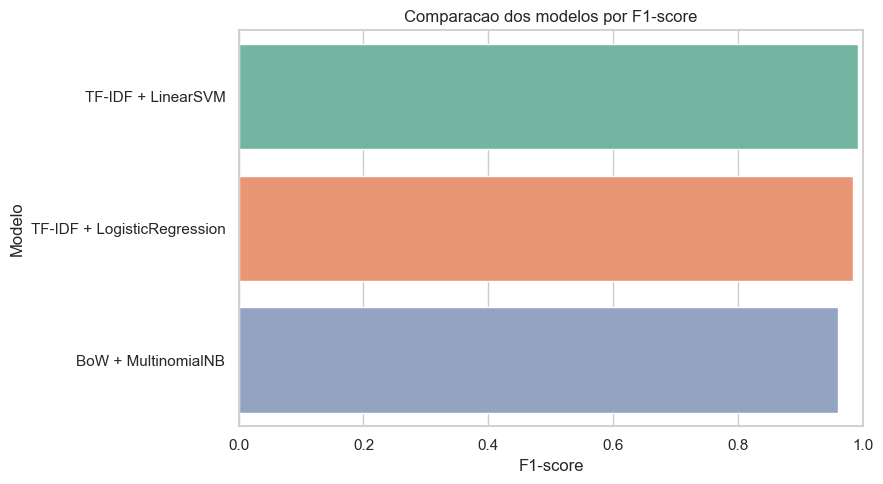

In [16]:
# Visualização comparativa dos modelos por F1-score
ax = sns.barplot(data=comparison, x="f1", y="model", hue="model", legend=False)
ax.set_title("Comparacao dos modelos por F1-score")
ax.set_xlabel("F1-score")
ax.set_ylabel("Modelo")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Após a comparação dos classificadores, é selecionado o modelo com melhor desempenho.

Nesta etapa são analisadas métricas mais detalhadas através do relatório de classificação, permitindo observar o desempenho individual em cada classe.

In [17]:
# Análise detalhada do melhor modelo
best_model_name = comparison.iloc[0]["model"]
best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

print("Melhor modelo:", best_model_name)
print(classification_report(y_test, y_pred, target_names=["true", "fake"], zero_division=0, digits=4))

Melhor modelo: TF-IDF + LinearSVM
              precision    recall  f1-score   support

        true     0.9894    0.9950    0.9922      4239
        fake     0.9941    0.9874    0.9908      3582

    accuracy                         0.9916      7821
   macro avg     0.9918    0.9912    0.9915      7821
weighted avg     0.9916    0.9916    0.9916      7821



A matriz de confusão permite visualizar os acertos e erros realizados pelo modelo.

Com esta análise é possível identificar:

- Quantas notícias falsas foram corretamente classificadas;
- Quantas notícias verdadeiras foram corretamente identificadas;
- Casos de falsos positivos e falsos negativos.

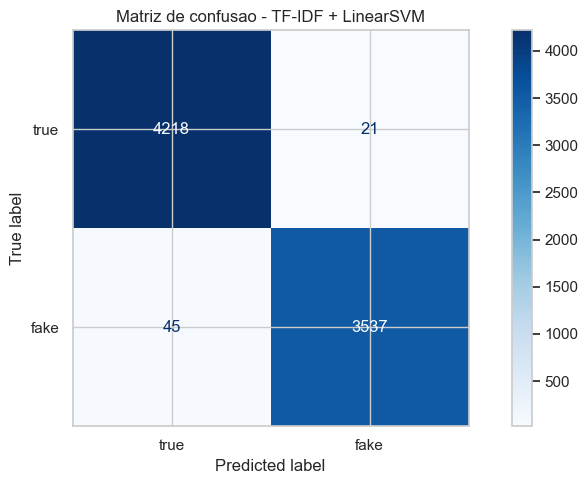

In [18]:
# Matriz de confusão do melhor modelo
matrix = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(matrix, display_labels=["true", "fake"])
display.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusao - {best_model_name}")
plt.tight_layout()
plt.show()

A curva ROC é utilizada para avaliar a capacidade de separação entre classes.

Quanto maior a área sob a curva (AUC), melhor é a capacidade do modelo em distinguir notícias falsas de notícias verdadeiras.

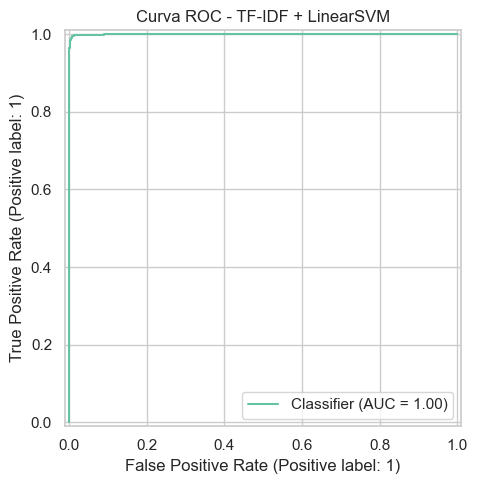

In [19]:
# Curva ROC do melhor modelo
if hasattr(best_model, "predict_proba"):
    RocCurveDisplay.from_predictions(y_test, best_model.predict_proba(X_test)[:, 1])
elif hasattr(best_model, "decision_function"):
    RocCurveDisplay.from_predictions(y_test, best_model.decision_function(X_test))
plt.title(f"Curva ROC - {best_model_name}")
plt.tight_layout()
plt.show()

### Interpretabilidade dos dados
Além da avaliação quantitativa, é importante compreender quais características influenciam as previsões do modelo.

Nesta secção são analisados os termos mais relevantes utilizados pelo classificador para distinguir notícias falsas e verdadeiras.

In [20]:
# Função para mostrar os termos mais importantes de um modelo linear
def show_linear_terms(pipeline, top_n):
    vectorizer = pipeline.named_steps["vectorizer"] # Acessa o vetor de características do pipeline
    classifier = pipeline.named_steps["model"] # Acessa o modelo de classificação do pipeline
    # Verifica se o modelo tem coeficientes lineares interpretáveis
    terms = np.array(vectorizer.get_feature_names_out())
    coefficients = classifier.coef_[0]

    # Cria DataFrames para os termos mais associados a "fake" e "true", ordenados por peso
    top_fake = pd.DataFrame({
        "term": terms[np.argsort(coefficients)[-top_n:]][::-1],
        "weight": np.sort(coefficients)[-top_n:][::-1],
        "class": "fake",
    })
    top_true = pd.DataFrame({
        "term": terms[np.argsort(coefficients)[:top_n]],
        "weight": np.sort(coefficients)[:top_n],
        "class": "true",
    })
    return pd.concat([top_fake, top_true], ignore_index=True)

# Mostrar os termos mais importantes do modelo linear
linear_model_name = "TF-IDF + LogisticRegression"
if linear_model_name in fitted_models:
    important_terms = show_linear_terms(fitted_models[linear_model_name], top_n=20)
    important_terms.head(10)
else:
    print("Modelo linear nao encontrado.")

### Termos importantes
Através dos coeficientes do modelo linear é possível identificar as palavras com maior impacto na classificação.

Os termos com pesos positivos e negativos mais elevados representam palavras fortemente associadas a uma das classes.

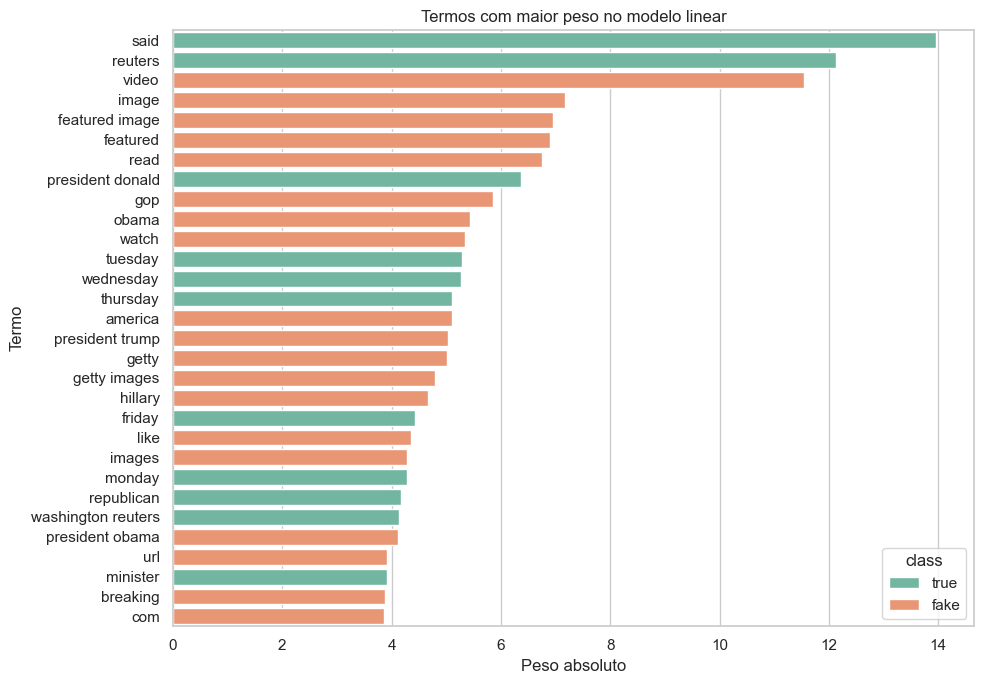

In [21]:
# Visualização dos termos mais importantes do modelo linear
if "important_terms" in globals():
    plt.figure(figsize=(10, 7))
    plot_terms = important_terms.copy()
    plot_terms["abs_weight"] = plot_terms["weight"].abs()
    ax = sns.barplot(
        data=plot_terms.sort_values("abs_weight", ascending=False).head(30),
        x="abs_weight",
        y="term",
        hue="class",
    )
    ax.set_title("Termos com maior peso no modelo linear")
    ax.set_xlabel("Peso absoluto")
    ax.set_ylabel("Termo")
    plt.tight_layout()
    plt.show()

## Recuperação de Informação por Similaridade
Nesta etapa é implementado um sistema simples de recuperação de informação baseado em similaridade textual.

Os documentos são representados utilizando TF-IDF e a similaridade entre textos é calculada através da similaridade do cosseno.

In [22]:
# Usamos uma amostra para a matriz de similaridade nao ficar demasiado pesada.
retrieval_df = df_total.sample(min(len(df_total), 6000), random_state=RANDOM_STATE).reset_index(drop=True)

# Criar um vetor TF-IDF para os documentos e calcular similaridades para um exemplo de consulta
retrieval_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    max_features=30000,
    sublinear_tf=True,
)

# Gerar a matriz TF-IDF para os documentos
tfidf_matrix = retrieval_vectorizer.fit_transform(retrieval_df["clean_document"])
query_index = 0 # Índice do documento de consulta para o qual queremos encontrar os mais similares
similarities = cosine_similarity(tfidf_matrix[query_index], tfidf_matrix).ravel() # Calcula a similaridade do documento de consulta com todos os outros documentos
nearest = similarities.argsort()[::-1][1:6] # Pega os 5 mais similares, ignorando o próprio documento (índice 0)

# Criar um DataFrame para mostrar os exemplos de recuperação
query = retrieval_df.loc[query_index]
retrieval_examples = []
for rank, idx in enumerate(nearest, start=1):
    candidate = retrieval_df.loc[idx]
    retrieval_examples.append({
        "query_title": query["title"],
        "query_label": query["label_name"],
        "rank": rank,
        "similarity": similarities[idx],
        "candidate_title": candidate["title"],
        "candidate_label": candidate["label_name"],
        "candidate_subject": candidate["subject"],
    })

# Mostrar os exemplos de recuperação
retrieval_examples = pd.DataFrame(retrieval_examples)
retrieval_examples

,query_title,query_label,rank,similarity,candidate_title,candidate_label,candidate_subject
0,Trump says Amazon.com has 'a huge antitrust pr...,true,1,0.307226,Bezos-Owned Washington Post Running PR for Bez...,fake,Middle-east
1,Trump says Amazon.com has 'a huge antitrust pr...,true,2,0.191455,JUST IN: WASHINGTON POST Gets DESTROYED When R...,fake,politics
2,Trump says Amazon.com has 'a huge antitrust pr...,true,3,0.158258,Amazon Facing Mounting Pressure To Stop Fundi...,fake,News
3,Trump says Amazon.com has 'a huge antitrust pr...,true,4,0.128411,Factbox: Trump to meet tech leaders from Googl...,true,politicsNews
4,Trump says Amazon.com has 'a huge antitrust pr...,true,5,0.126283,U.S. senator urges DOJ to reject any White Hou...,true,politicsNews


## Aprendizagem Não Supervisionada
Para complementar a análise supervisionada, também fazemos aprendizagem não supervisionada. É aplicada uma abordagem de clustering utilizando o algoritmo K-Means.

O objetivo é verificar se os documentos formam grupos naturais com base no conteúdo textual, mesmo sem utilizar as classes reais.

Antes da clusterização, é aplicada redução de dimensionalidade com SVD para facilitar a representação dos dados.

In [28]:
# Clusterização usando KMeans e avaliação dos clusters formados
cluster_df = df_total.sample(min(len(df_total), 10000), random_state=RANDOM_STATE).reset_index(drop=True)
cleaned_docs = cluster_df["clean_document"]

# Criar a matriz TF-IDF para os documentos e reduzir a dimensionalidade com SVD para facilitar a clusterização
cluster_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    max_features=30000,
    sublinear_tf=True,
)
cluster_tfidf = cluster_vectorizer.fit_transform(cleaned_docs)

# Reduzir a dimensionalidade para 100 componentes principais usando SVD
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
cluster_reduced = svd.fit_transform(cluster_tfidf)

# Aplicar KMeans para formar 2 clusters e avaliar a qualidade dos clusters usando métricas de agrupamento
kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(cluster_reduced)

# Calcular métricas de avaliação de clusterização comparando os clusters formados com as classes reais
cluster_metrics = {
    "adjusted_rand_index": adjusted_rand_score(cluster_df["label"], clusters),
    "normalized_mutual_info": normalized_mutual_info_score(cluster_df["label"], clusters),
    "svd_explained_variance": svd.explained_variance_ratio_.sum(),
}

# Criar um resumo dos clusters formados, mostrando a contagem de documentos por cluster e classe
cluster_summary = (
    pd.DataFrame({"cluster": clusters, "label_name": cluster_df["label_name"]})
    .value_counts(["cluster", "label_name"])
    .reset_index(name="documents")
    .sort_values(["cluster", "documents"], ascending=[True, False])
)

# Criar uma cópia para calcular as percentagens
df_percentages = cluster_summary.copy()

# Calcular a percentagem de cada label dentro do seu respectivo cluster
df_percentages['%_in_cluster'] = (
    df_percentages['documents'] / 
    df_percentages.groupby('cluster')['documents'].transform('sum') * 100
).round(2)

# Ver apenas o total de documentos por cluster
print("\n--- Total de documentos por Cluster ---")
print(cluster_summary.groupby('cluster')['documents'].sum())

# Exibir o resultado formatado
print("--- Percentagem de composição por Cluster ---")
print(df_percentages.to_string(index=False))

cluster_metrics


--- Total de documentos por Cluster ---
cluster
0    4819
1    5181
Name: documents, dtype: int64
--- Percentagem de composição por Cluster ---
 cluster label_name  documents  %_in_cluster
       0       fake       4213         87.42
       0       true        606         12.58
       1       true       4802         92.68
       1       fake        379          7.32


{'adjusted_rand_index': 0.6447706567090427,
 'normalized_mutual_info': 0.5381573933723962,
 'svd_explained_variance': np.float64(0.12789458022475114)}

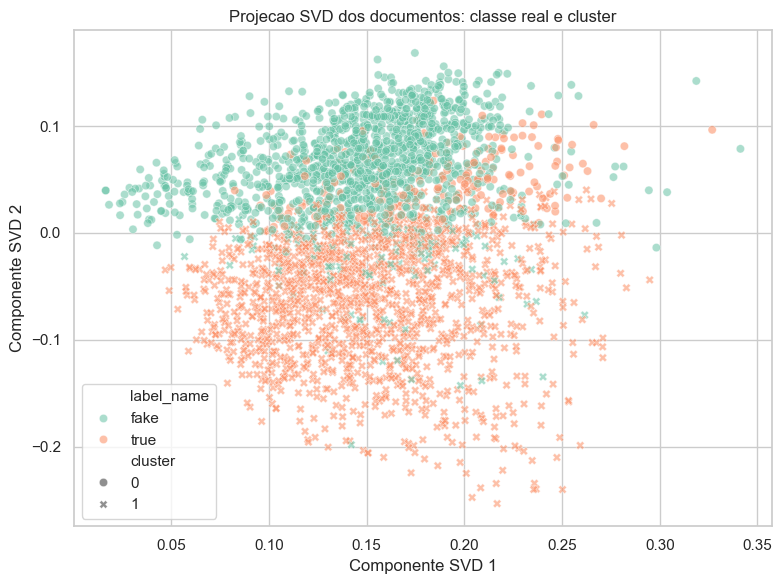

In [25]:
# Visualização da projeção SVD dos documentos, colorida pela classe real e estilo pelo cluster formado
plot_cluster_df = pd.DataFrame({
    "svd_1": cluster_reduced[:, 0],
    "svd_2": cluster_reduced[:, 1],
    "cluster": clusters.astype(str),
    "label_name": cluster_df["label_name"],
})

# Para evitar sobrecarregar a visualização, amostramos um subconjunto dos dados para o scatter plot
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=plot_cluster_df.sample(min(len(plot_cluster_df), 3000), random_state=RANDOM_STATE),
    x="svd_1",
    y="svd_2",
    hue="label_name",
    style="cluster",
    alpha=0.55,
)
ax.set_title("Projecao SVD dos documentos: classe real e cluster")
ax.set_xlabel("Componente SVD 1")
ax.set_ylabel("Componente SVD 2")
plt.tight_layout()
plt.show()

# Testar uma Notícia Nova

In [26]:
# Criar um novo documento a partir do título e texto fornecidos, limpar o texto e fazer a previsão usando o melhor modelo
new_title = "Trump says US-Iran ceasefire still in place after exchange of fire in Strait of Hormuz"
new_text = "US President Donald Trump says a ceasefire is still in place with Iran, despite a clash between Iran and US naval destroyers in the Strait of Hormuz for which both sides blamed the other. The US said Iran launched missiles, drones and small boats against three of its warships, in what it called an unprovoked attack. Trump said Iran trifled with us today. Iran's top military command, meanwhile, alleged the US had targeted an Iranian oil tanker and another vessel approaching the Strait of Hormuz and carried out aerial attacks on several coastal areas.The flare-up comes a day after Iran's foreign ministry had said it was considering a US proposal to end the war. In a further sign of the fragility of the ceasefire, early on Friday the United Arab Emirates' Ministry of Defence said its air defences were actively engaging with an missile and drone attack from Iran. Iranian state media initially reported explosions in the Strait of Hormuz, describing them as an exchange of fire with the enemy. Meanwhile, local media reported explosions were heard in Tehran. Not long after, a statement from Iran's top military command said US aerial attacks struck the coasts of Bandar Khamir, Sirik and Qeshm Island. It said it responded immediately by attacking US military vessels, inflicting significant damage, and accused the US of a violation of the ceasefire. US Central Command (Centcom) described the Iranian attacks as unprovoked, saying Iranian forces launched multiple missiles, drones and small boats as US Navy guided-missile destroyers transited through the strait. Centcom said it had eliminated inbound threats and targeted Iranian military facilities responsible for attacking US forces, including missile and drone launch sites; command and control locations; and intelligence, surveillance and reconnaissance nodes. Centcom does not seek escalation but remains positioned and ready to protect American forces, the statement continued. Posting on Truth Social, Trump said that the US had destroyed multiple small boats, missiles and drones, adding that great damage was done to the Iranian attackers. The US president also reiterated a warning over the peace deal: Just like we knocked them out again today, we'll knock them out a lot harder, and a lot more violently, in the future, if they don't get their Deal signed, FAST! An Israeli source told the BBC there was no Israeli involvement in the latest attacks. The increase in tensions comes despite the US president saying in recent days that the war in Iran will be over quickly. US news outlet Axios had said that the White House believes it could be closing in on a 14-point memorandum of understanding with Iran, which could set a framework for more detailed nuclear negotiations. On Wednesday, an Iranian foreign ministry spokesman said the latest US proposal was being considered and that Tehran would share its views with Pakistani mediators. Pakistan's foreign minister said his country was endeavouring to convert this ceasefire into a permanent end to this war. But a senior member of Iran's parliament has dismissed the 14-point memorandum of understanding as a wish list. The spokesperson of the Iranian parliament's national security and foreign policy commission, Ebrahim Rezaei, wrote on X that Iran has its finger on the trigger, warning Iran would deliver a harsh and regret-inducing response if the US did not surrender and grant necessary conditions. Both the US and Iran have threatened an escalation in violence if their respective conditions for a peace deal aren't met. In a Truth Social post on 6 May, Trump wrote that if Iran did not agree to a deal the bombing starts, and it will be, sadly, at a much higher level and intensity than it was before. Trump had previously said Operation Epic Fury - the initial US-Israeli offensive in Iran - would come to an end assuming Iran agrees to give what has been agreed to. Prior to this statement, US Secretary of State Marco Rubio had said the operation was over and had achieved its objectives. Trump also said, not for the first time, that Iran had agreed to never have a nuclear weapon among other things - a claim that has not been confirmed by Tehran. Iran's nuclear programme has been one of the key sticking points between the two sides."

new_document = f"{new_title}. {new_text}"
new_clean_document = clean_text(new_document)
prediction = int(best_model.predict([new_clean_document])[0])
label = "fake" if prediction == 1 else "true"

# Exibir a previsão e, se possível, a confiança do modelo para a previsão
print("Previsão:", label)
if hasattr(best_model, "predict_proba"):
    confidence = best_model.predict_proba([new_clean_document])[0][prediction]
    print(f"Confiança aproximada: {confidence:.3f}")

Previsão: true
